In [1]:
# Quantum simulation libraries
from qutip import (
    basis, 
    mesolve, 
    qeye, 
    sigmax, 
    sigmay, 
    sigmaz, 
    tensor,
    )
import qutip

# Machine learning libraries
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# Plotting libraries
import matplotlib.pyplot as plt
from rich.progress import track
import seaborn as sns

# Linalg libraries
import numpy as np
from scipy.stats import pearsonr
from scipy.integrate import odeint

# Helper libraries
from dataclasses import dataclass


In [2]:
# set the device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


# Load target data

In [3]:
class BFieldGenerator:
    def __init__(
        self,  sigma: float, rho: float, beta: float, initial_state: list, scale: float = 1, times: list = None
        ):
        """
        Create the BField generator for the Lorenz Oscillator.
        """
        self.sigma = sigma
        self.rho = rho
        self.beta = beta
        self.initial_state = initial_state
        self.scale_factor = scale

        self.counter = 0

        self.measured_field = [initial_state]
        self.measured_times = [0.0]
        self.times = times

    def _lorenz_system(self, state, t):
        """
        Lorenz system differential equations
        """
        x = state[0]
        y = state[1]
        z = state[2]

        dx_dt = self.sigma * (y - x)
        dy_dt = x * (self.rho - z) - y
        dz_dt = x * y - self.beta * z

        x_new = x + dx_dt * t
        y_new = y + dy_dt * t
        z_new = z + dz_dt * t
        
        return [x_new, y_new, z_new]

    def __call__(self, t: float):
        """
        Get the next value of the magnetic field.

        Parameters
        ----------
        t : float
            Current time.
        """
        if t == self.times[self.counter]:
            driving_field = np.array(self._lorenz_system(self.measured_field[-1], t - self.measured_times[-1]))

            self.measured_field.append(driving_field)      
            self.measured_times.append(t)
            self.counter += 1
        else:
            driving_field = self.measured_field[-1]

        return np.array(driving_field) / self.scale_factor

# Run Simulation

In [4]:
@dataclass
class SimulationParameters:
    """
    Helper class for the simulation parameters.
    """
    length: int
    coupling: list

@dataclass
class SimulationState:
    """ 
    Helper class for the simulation state.
    """
    number_of_spins: int
    quantum_state: list
    spin_list: list
    coupling_list: list

In [5]:
def get_simulation_state(parameters: SimulationParameters):
    """
    Returns the initial state of the simulation.
    """
    # Get the initial wavefunction
    number_of_spins = parameters.length
    initial_state = [basis(2, 1)] + [basis(2, 0)] * (number_of_spins - 1)

    # Setup operators for individual qubits
    sx_list, sy_list, sz_list = [], [], []
    for i in range(number_of_spins):
        op_list = [qeye(2)] * number_of_spins
        op_list[i] = sigmax()
        sx_list.append(tensor(op_list))
        op_list[i] = sigmay()
        sy_list.append(tensor(op_list))
        op_list[i] = sigmaz()
        sz_list.append(tensor(op_list))

    # Setup the operators for the coupling
    Jx = parameters.coupling * np.ones(number_of_spins)
    Jy = parameters.coupling * np.ones(number_of_spins)
    Jz = parameters.coupling * np.ones(number_of_spins)    

    return SimulationState(
        number_of_spins=number_of_spins,
        quantum_state=tensor(initial_state),
        spin_list=[sx_list, sy_list, sz_list],
        coupling_list=[Jx, Jy, Jz],
    )

In [161]:
def compute_hamiltonian(t, args):
    """
    Compute the Hamiltonian at time t.
    
    Parameters
    ----------
    t : float
        Current time.
    args : dict
        System parameters in the H computation.
    """
    sx_list = args["sx_list"]
    sy_list = args["sy_list"]
    sz_list = args["sz_list"]
    Jx = args["Jx"]
    Jy = args["Jy"]
    Jz = args["Jz"]
    driving_field = args["driving"]

    N = args["N"]

    # Magnetic field terms to top row
    H = 0
    field_values = driving_field(t)

    H -= field_values[0] * sz_list[0]
    H -= field_values[1] * sx_list[2]
    H -= field_values[2] * sy_list[4]

    # Interaction terms
    for n in range(N - 1):
        H += -0.5 * Jx[n] * sx_list[n] * sx_list[n + 1]
        H += -0.5 * Jy[n] * sy_list[n] * sy_list[n + 1]
        H += -0.5 * Jz[n] * sz_list[n] * sz_list[n + 1]

    return H

In [372]:
sigma=10
rho=28
beta=8/3

times = np.linspace(0, 50, 5000)


In [373]:
# for strength in np.linspace(1, 10, 10, dtype=int):
simulation_parameters = SimulationParameters(
    length=5,
    coupling=0.5 * np.pi,
)
simulation_state = get_simulation_state(simulation_parameters)

sigma=10
rho=28
beta=8/3
field_generator = BFieldGenerator(sigma, rho, beta, [1., 1., 1.], times=times, scale=50.48297185244022)

args = {
    "sx_list": simulation_state.spin_list[0],
    "sy_list": simulation_state.spin_list[1],
    "sz_list": simulation_state.spin_list[2],
    "Jx": simulation_state.coupling_list[0],
    "Jy": simulation_state.coupling_list[1],
    "Jz": simulation_state.coupling_list[2],
    "N": simulation_state.number_of_spins,
    "driving": field_generator
}

In [374]:
results = mesolve(compute_hamiltonian, simulation_state.quantum_state, times, [], [], args)

In [375]:
measured_field = np.array(field_generator.measured_field)[1:]

In [376]:
fit_generator = BFieldGenerator(sigma, rho, beta, [1., 1., 1.], scale=50.48297185244022, times=times)
b_field = []
for t in times:
    b_field.append(fit_generator(t))

b_field = np.array(b_field)

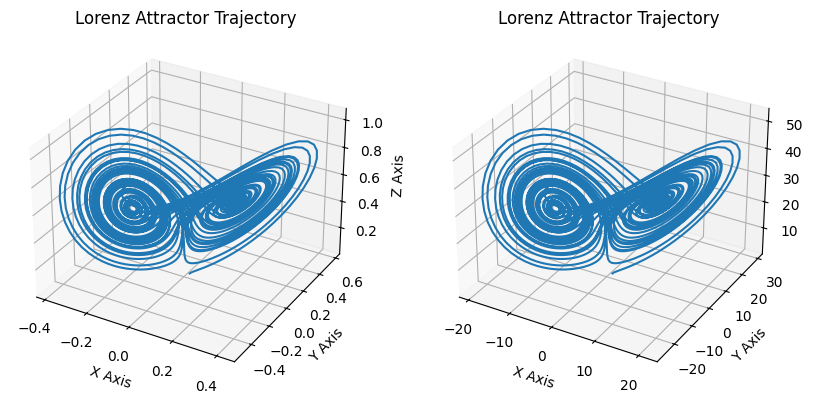

In [377]:
fig, al_ax = plt.subplots(1, 2, figsize=(10, 8), subplot_kw={"projection": "3d"})

ax = al_ax[0]
ax.plot(b_field[:, 0], b_field[:, 1], b_field[:, 2])

ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor Trajectory")

ax = al_ax[1]
ax.plot(measured_field[:, 0], measured_field[:, 1], measured_field[:, 2])

ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor Trajectory")

plt.show()

In [378]:
state_dimension = 10

measurements = []

for _ in range(state_dimension):
    non_gue_matrix = qutip.rand_herm(
        2**2, 
        1.0, 
        dims=[[2] * 2, [2] * 2]
    )
    measurements.append(non_gue_matrix)

In [379]:
measure_sites = []
for _ in range(state_dimension):
    measure_sites.append(
        np.random.choice(5, 2, replace=False)
    )

In [381]:
# Compute observables
observations = np.zeros((5000, state_dimension))
states = results.states[1:]

for t, state in enumerate(states):
    for o, operator in enumerate(measurements):
        measure_state = state.ptrace(measure_sites[o])
        observations[t][o] = qutip.expect(measure_state * measure_state.dag(), operator)

# Fit Model

In [382]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, state_dimension: int, output_dimension: int):
        """
        Build the network.
        
        Parameters
        ----------
        state_dimension : int
                Dimension of the state representation.
                This is the input to the layer.
        output_dimension : int
                Dimension of the output being predicted.
        """
        super().__init__()
        
        self.linear_stack = nn.Sequential(
            nn.Linear(state_dimension, 128),
            nn.ReLU(),
            nn.Linear(128, output_dimension)
        )
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        As we are doing reservoir computing, this is 
        simply a linear layer.
        """
        # return self.readout_layer(x)
        return self.linear_stack(x)

In [383]:
class ReservoirDataset(Dataset):
    """
    Custom dataset for the training.
    """
    def __init__(
        self, 
        state_data: np.ndarray, 
        prediction_length: int,
        function_data: np.ndarray,
    ):
        """
        Constructor for the dataset.

        Parameters
        ----------
        state_data : np.ndarray
                State description data.
        function_data : np.ndarray
                Function data being fit.
                This will be the target data.
        prediction_length : int
                How far into the future you will predict.
        """
        self.state_data = torch.Tensor(state_data).to(device)

        self.function_data = torch.Tensor(function_data).to(device)
        
        self.norm_factor = 1

    def split_data(self, train_size: float):
        """
        Split the data into training and validation sets.
        
        Parameters
        ----------
        train_size : float
                Size of the training set.
        """
        train_size = int(train_size * len(self))
        val_size = len(self) - train_size
        return torch.utils.data.random_split(self, [train_size, val_size])
    
    def __len__(self):
        """
        Length of the dataset.
        """
        return int(
            len(self.function_data)
        )
    
    def __getitem__(self, idx: int):
        """
        Collect an item from the dataset.
        
        Parameters
        ----------
        idx : int
                Index of the state to take.
        """
        state = self.state_data[idx]
        target = self.function_data[idx] / self.norm_factor
        
        return state, target

In [384]:
def train(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            
    return loss

In [385]:
def test(dataloader, model, loss_fn) -> np.ndarray:
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    
    return test_loss

In [386]:
def train_model(dataset, test_ds, model = None):
    """
    Train a model on the current data.
    """    
    if model is None:
        model = NeuralNetwork(
            state_dimension=10,
            output_dimension=3
        ).to(device)

        model = model.type(torch.float32)

    # Use MSE loss
    loss_fn = nn.MSELoss()

    # Use ADAM optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Create the loader
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    
    # Train the network
    epochs = 500
    train_losses = []
    test_losses = []

    for t in track(range(epochs)):
        loss = train(loader, model, loss_fn, optimizer)
        train_losses.append(loss)
        loss = test(test_loader, model, loss_fn)
        test_losses.append(loss)

    try:
        train_losses = [item.cpu().detach().numpy() for item in train_losses]
    except AttributeError:
        pass
    
    return train_losses, test_losses, model

## Train the model

In [397]:
prediction_length = 10
train_fraction = 0.7

mix_train_indices = np.random.choice(len(observations) - prediction_length - 1, int(train_fraction * len(observations)), replace=False)
mix_test_indices = np.array([i for i in range(len(observations) - prediction_length - 1) if i not in mix_train_indices])

sequence_train_indices = np.linspace(0, int(train_fraction * len(observations)), int(train_fraction * len(observations)), dtype=int)
sequence_test_indices = np.array([i for i in range(len(observations) - prediction_length - 1) if i not in sequence_train_indices])

train_indices = mix_train_indices
test_indices = mix_test_indices

train_dataset = ReservoirDataset(
    state_data=observations[train_indices],
    function_data=b_field[train_indices + prediction_length],
    prediction_length=1
)

test_dataset = ReservoirDataset(
    state_data=observations[test_indices],
    function_data=b_field[test_indices + prediction_length],
    prediction_length=1
)
train_losses, test_losses, model = train_model(train_dataset, test_dataset, model=None)

Output()

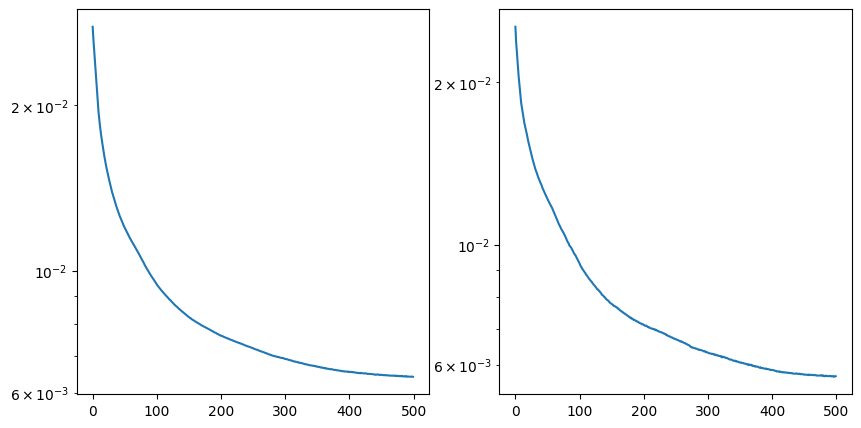

In [398]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(test_losses)
ax[1].plot(train_losses)

ax[1].set_yscale("log")
ax[0].set_yscale("log")

plt.show()

In [399]:
test_predictions = []
test_targets = []
for item in test_dataset:
    state, target = item
    test_predictions.append(model(state).cpu().detach().numpy())
    test_targets.append(target.cpu().detach().numpy())

test_predictions = np.array(test_predictions)
test_targets = np.array(test_targets)

train_predictions = []
train_targets = []
for item in train_dataset:
    state, target = item
    train_predictions.append(model(state).cpu().detach().numpy())
    train_targets.append(target.cpu().detach().numpy())

train_predictions = np.array(train_predictions)
train_targets = np.array(train_targets)

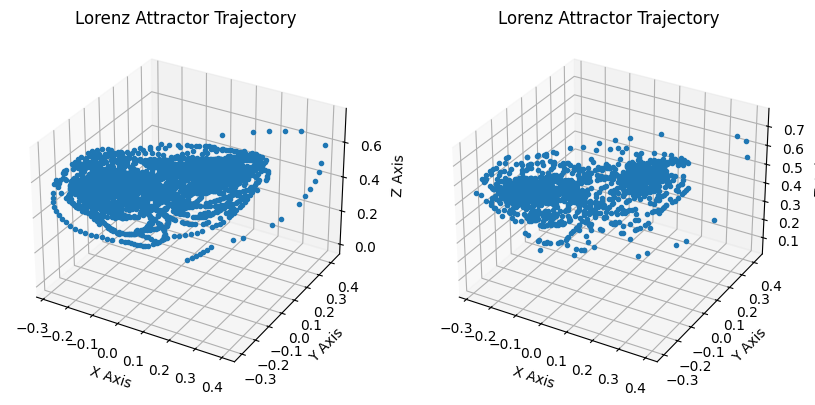

In [400]:
fig, al_ax = plt.subplots(1, 2, figsize=(10, 8), subplot_kw={"projection": "3d"})

ax = al_ax[0]
ax.plot(train_predictions[:, 0], train_predictions[:, 1], train_predictions[:, 2], '.')
# ax.plot(train_targets[:, 0], train_targets[:, 1], train_targets[:, 2], '.')

ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor Trajectory")

ax = al_ax[1]
ax.plot(test_predictions[:, 0], test_predictions[:, 1], test_predictions[:, 2], '.')
# ax.plot(test_targets[:, 0], test_targets[:, 1], test_targets[:, 2], '.')

ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz Attractor Trajectory")

plt.show()

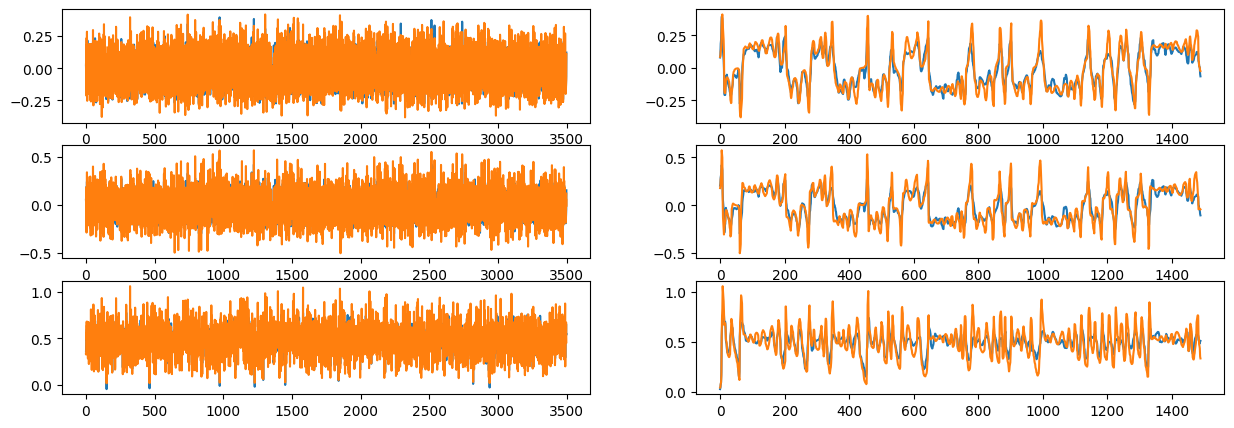

In [401]:
fig, ax = plt.subplots(3, 2, figsize=(15, 5))

ax[0][1].plot(test_predictions[:, 0])
ax[0][1].plot(test_targets[:, 0])

ax[0][0].plot(train_predictions[:, 0])
ax[0][0].plot(train_targets[:, 0])

ax[1][1].plot(test_predictions[:, 1])
ax[1][1].plot(test_targets[:, 1])

ax[1][0].plot(train_predictions[:, 1])
ax[1][0].plot(train_targets[:, 1])

ax[2][1].plot(test_predictions[:, 2])
ax[2][1].plot(test_targets[:, 2])

ax[2][0].plot(train_predictions[:, 2])
ax[2][0].plot(train_targets[:, 2])


plt.show()